In [2]:
#importing the libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("Housing.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

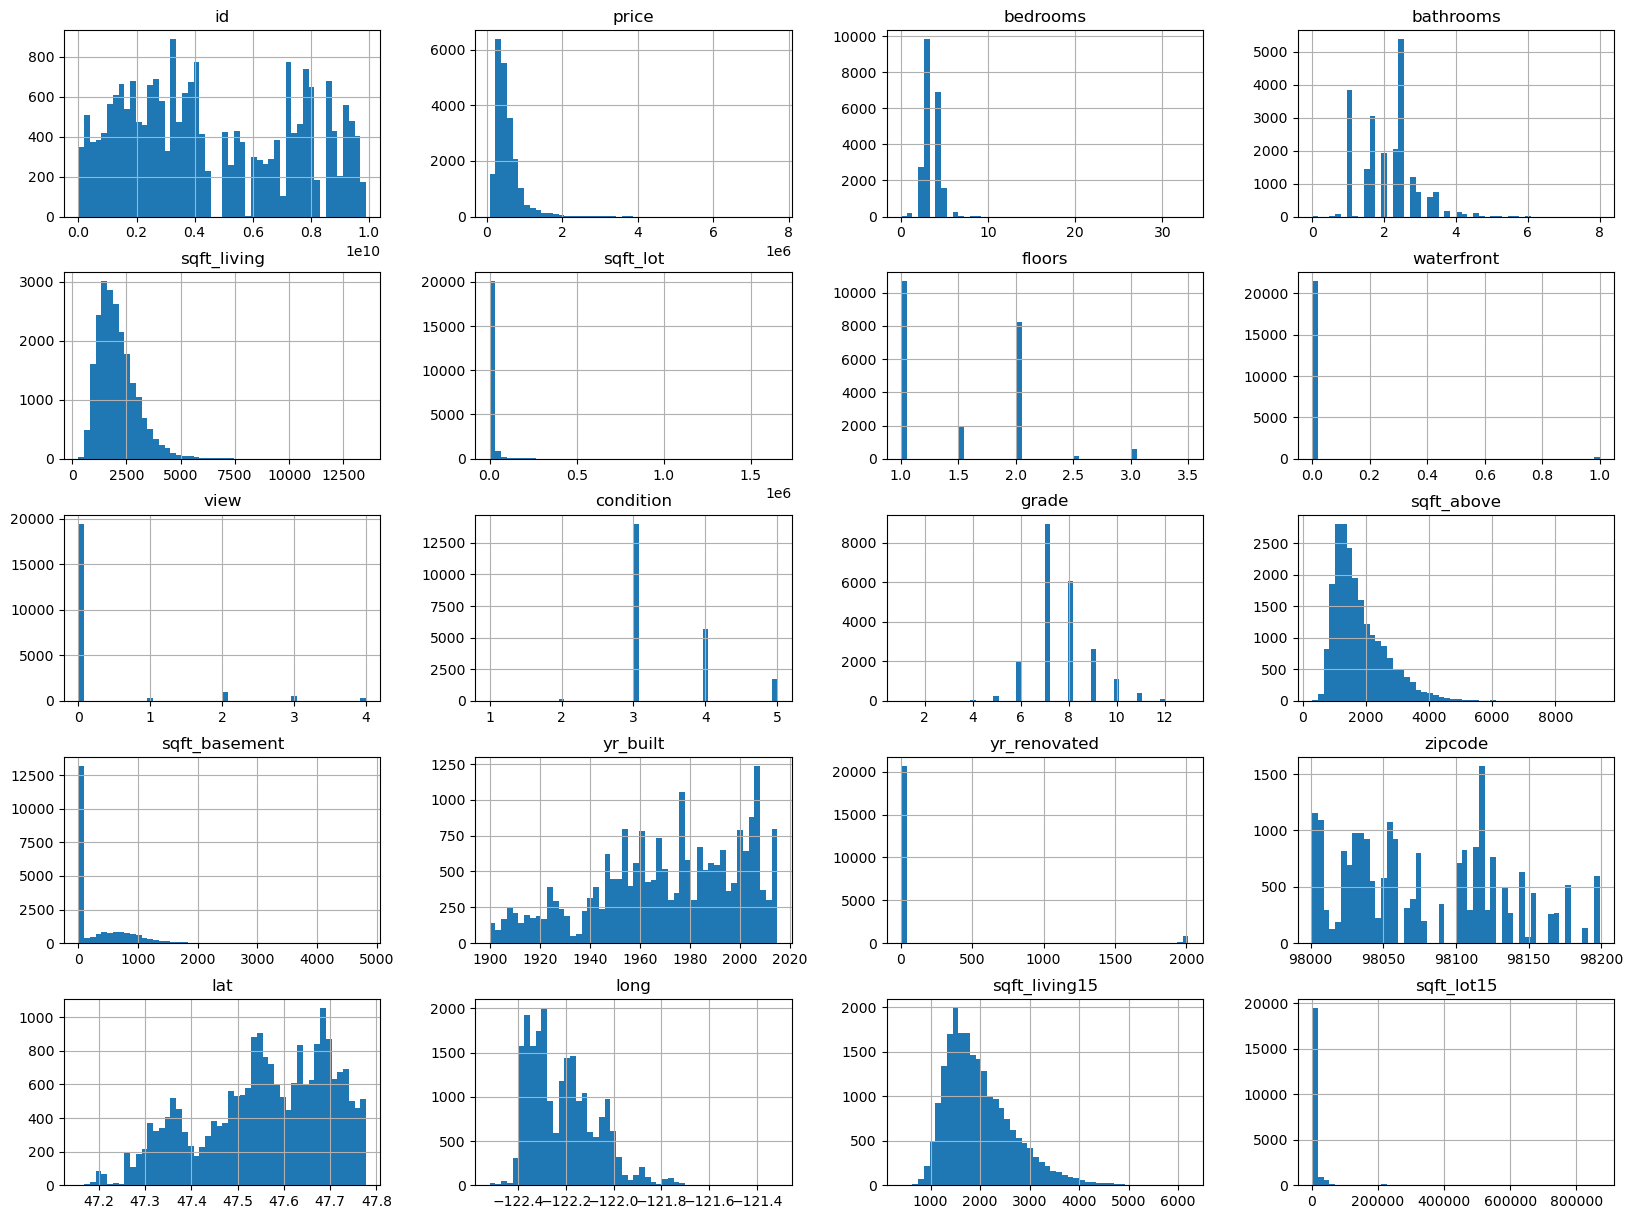

In [5]:
df.hist(bins = 50, figsize=(20,15))
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size = 0.2, random_state=42) #42 is a random number doesnt mean anything just a homage to hitchikers guide to galaxy
print(f"Training data size: {len(train_set)} rows")
print(f"Test data size: {len(test_set)} rows")

housing_train = train_set.copy()
housing_train.head()



Training data size: 17290 rows
Test data size: 4323 rows


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
6325,5467910190,20140527T000000,325000.0,3,1.75,1780,13095,1.0,0,0,...,9,1780,0,1983,0,98042,47.3670,-122.152,2750,13095
13473,9331800580,20150310T000000,257000.0,2,1.00,1000,3700,1.0,0,0,...,6,800,200,1929,0,98118,47.5520,-122.290,1270,5000
17614,2407000405,20150226T000000,228500.0,3,1.00,1080,7486,1.5,0,0,...,6,990,90,1942,0,98146,47.4838,-122.335,1170,7800
16970,5466700290,20150108T000000,288000.0,3,2.25,2090,7500,1.0,0,0,...,7,1280,810,1977,0,98031,47.3951,-122.172,1800,7350
20868,3026059361,20150417T000000,479000.0,2,2.50,1741,1439,2.0,0,0,...,8,1446,295,2007,0,98034,47.7043,-122.209,2090,10454


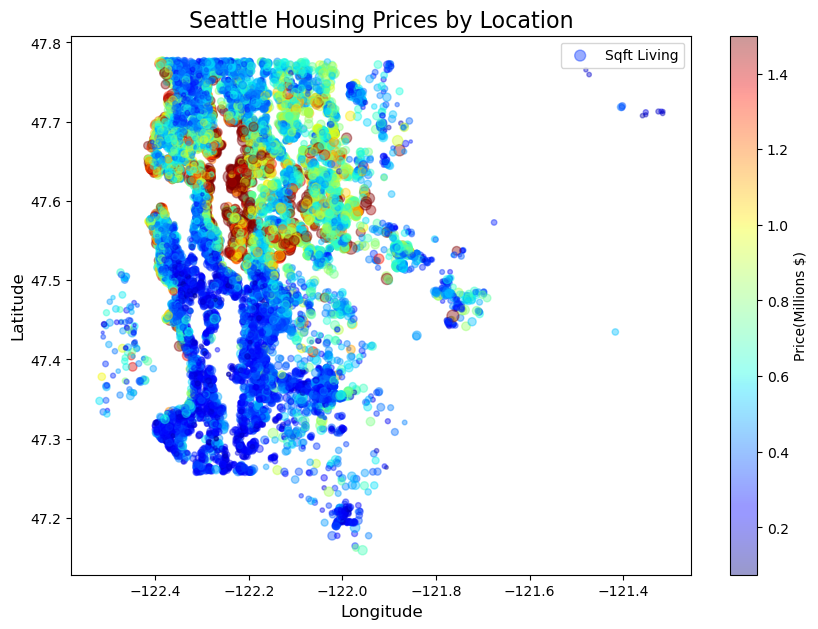

In [24]:
housing_train["Price(Millions $)"] = housing_train["price"] / 1000000
ax = housing_train.plot(kind = "scatter", x = "long", y = "lat", alpha = 0.4,
s = housing_train["sqft_living"]/100, label = "Sqft Living",figsize = (10,7),
c = "Price(Millions $)",cmap = plt.get_cmap("jet"),
colorbar = True,
sharex = False, vmax = 1.5)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("Seattle Housing Prices by Location", fontsize=16)
plt.legend()
plt.show()




In [29]:
corr_matrix = housing_train.corr(numeric_only=True)
print(corr_matrix['price'].sort_values(ascending = False))

price                1.000000
Price(Millions $)    1.000000
sqft_living          0.701700
grade                0.665093
sqft_above           0.603255
sqft_living15        0.582666
bathrooms            0.526616
view                 0.392108
sqft_basement        0.321387
lat                  0.310770
bedrooms             0.308297
floors               0.253424
waterfront           0.252946
yr_renovated         0.127737
sqft_lot             0.091039
sqft_lot15           0.079152
yr_built             0.049099
condition            0.036343
long                 0.023485
id                  -0.020624
zipcode             -0.053800
Name: price, dtype: float64
